In [1]:
# ============================================================
# Level 3 Data Science - Second Term Project
# GitHub Machine Learning Repository Analysis
# ============================================================

In [2]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# TASK 1 - BUILD THE DATA COLLECTION PIPELINE
# ============================================================

In [4]:
print("=" * 60)
print("TASK 1 - DATA COLLECTION AND PREPARATION")
print("=" * 60)

TASK 1 - DATA COLLECTION AND PREPARATION


In [5]:
# ------------------------------------------------------------
# Step 1: Collect API Data
# ------------------------------------------------------------

In [6]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

In [7]:
# Check whether the API request was successful
response.raise_for_status()

In [8]:
# Convert JSON response
data = response.json()

In [9]:
print("\nAPI data collected successfully.")


API data collected successfully.


In [10]:
# ------------------------------------------------------------
# Step 2: Create the Dataset
# ------------------------------------------------------------

In [11]:
repositories = data["items"]

df = pd.DataFrame(repositories)

print("\nFirst 5 rows of raw data:")
print(df.head())


First 5 rows of raw data:
          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id

In [12]:
print("\nRaw dataset shape:")
print(df.shape)


Raw dataset shape:
(100, 82)


In [13]:
print("\nAvailable columns:")
print(df.columns.tolist())


Available columns:
['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url', 'description', 'fork', 'url', 'forks_url', 'keys_url', 'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url', 'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url', 'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url', 'languages_url', 'stargazers_url', 'contributors_url', 'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url', 'comments_url', 'issue_comment_url', 'contents_url', 'compare_url', 'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url', 'milestones_url', 'notifications_url', 'labels_url', 'releases_url', 'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url', 'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size', 'stargazers_count', 'watchers_count', 'language', 'has_issues', 'has_projects', 'has_downloads', 'has_wiki', 'has_pages', 'has_discussions', 'forks_count', 'mirror_url', 'archived', 'disable

In [14]:
# ------------------------------------------------------------
# Step 3: Select Required Columns
# ------------------------------------------------------------

In [15]:
required_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[required_columns].copy()

print("\nRequired columns selected successfully.")


Required columns selected successfully.


In [16]:
# ------------------------------------------------------------
# Step 4: Extract Required Values
# ------------------------------------------------------------

In [17]:
# Extract repository owner's username
df["owner"] = df["owner"].apply(
    lambda x: x.get("login") if isinstance(x, dict) else None
)

In [18]:
# Extract license name
df["license"] = df["license"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)

print("\nNested values extracted successfully.")


Nested values extracted successfully.


In [19]:
# ------------------------------------------------------------
# Step 5: Handle Missing Values
# ------------------------------------------------------------

In [20]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64


In [21]:
# Missing programming language
df["language"] = df["language"].fillna("Unknown")

In [22]:
# Missing license
df["license"] = df["license"].fillna("No License")

In [23]:
# Missing owner, if any
df["owner"] = df["owner"].fillna("Unknown")

In [24]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


In [25]:
# ------------------------------------------------------------
# Step 6: Handle Duplicate Records
# ------------------------------------------------------------

In [26]:
duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate records:", duplicate_count)

df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:")
print(df.shape)


Number of duplicate records: 0
Dataset shape after removing duplicates:
(100, 10)


In [27]:
# ------------------------------------------------------------
# Step 7: Prepare the Dataset
# ------------------------------------------------------------

In [28]:
# Convert dates
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [29]:
# Rename columns
df.rename(
    columns={
        "stargazers_count": "stars",
        "forks_count": "forks",
        "watchers_count": "watchers",
        "open_issues_count": "open_issues",
        "created_at": "created_date",
        "updated_at": "updated_date"
    },
    inplace=True
)

In [30]:
print("\nDataset prepared successfully.")

print("\nFinal columns:")
print(df.columns.tolist())


Dataset prepared successfully.

Final columns:
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


In [31]:
# ------------------------------------------------------------
# Step 8: Save and Verify Dataset
# ------------------------------------------------------------

In [32]:
csv_file = "github_projects.csv"

df.to_csv(
    csv_file,
    index=False
)

print(f"\nDataset saved as: {csv_file}")


Dataset saved as: github_projects.csv


In [33]:
# Reload CSV to verify
df_check = pd.read_csv(csv_file)

print("\nReloaded dataset:")
print(df_check.head())

print("\nReloaded dataset shape:")
print(df_check.shape)

print("\nDataset verification completed successfully.")


Reloaded dataset:
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197040  76059   
1              transformers     huggingface            Python  164218  34267   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89485  21967   
3                    funNLP  fighting41love            Python   82526  15264   
4  awesome-machine-learning    josephmisiti            Python   74061  15612   

   watchers  open_issues               created_date  \
0    197040         2980  2015-11-07 01:19:20+00:00   
1    164218         2365  2018-10-29 13:56:00+00:00   
2     89485           11  2021-03-03 01:34:05+00:00   
3     82526           52  2018-08-21 11:20:39+00:00   
4     74061           26  2014-07-15 19:11:19+00:00   

                updated_date             license  
0  2026-08-18 17:36:14+00:00  Apache License 2.0  
1  2026-08-18 16:49:37+00:00  Apache License 2.0  
2  2026-08-18 17

In [34]:
# ============================================================
# TASK 2 - STORE AND ANALYZE THE DATA
# ============================================================

In [35]:
print("\n" + "=" * 60)
print("TASK 2 - SQLITE AND DATA ANALYSIS")
print("=" * 60)


TASK 2 - SQLITE AND DATA ANALYSIS


In [36]:
# ------------------------------------------------------------
# Step 1: Create SQLite Database
# ------------------------------------------------------------

In [37]:
database_file = "github_projects.db"

connection = sqlite3.connect(database_file)

In [38]:
# Import CSV data into SQLite
df.to_sql(
    "Repositories",
    connection,
    if_exists="replace",
    index=False
)

print("\nSQLite database created successfully.")
print("Table 'Repositories' created successfully.")


SQLite database created successfully.
Table 'Repositories' created successfully.


In [39]:
# ------------------------------------------------------------
# Step 2: Filtering & Searching Queries
# ------------------------------------------------------------

In [40]:
# Query 1:
# Repositories with more than 10,000 stars

query_1 = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""

result_1 = pd.read_sql_query(
    query_1,
    connection
)

print("\n--- Repositories with more than 10,000 stars ---")
print(result_1)


--- Repositories with more than 10,000 stars ---
                               name           owner          language   stars  \
0                        tensorflow      tensorflow               C++  197040   
1                      transformers     huggingface            Python  164218   
2                  ML-For-Beginners       microsoft  Jupyter Notebook   89485   
3                            funNLP  fighting41love            Python   82526   
4          awesome-machine-learning    josephmisiti            Python   74061   
..                              ...             ...               ...     ...   
65  machine-learning-systems-design       chiphuyen              HTML   10527   
66                 Machine-Learning    Jack-Cherish            Python   10370   
67           machine-learning-notes      roboticcam  Jupyter Notebook   10331   
68              3D-Machine-Learning     timzhang642           Unknown   10193   
69                             tpot    EpistasisLab  Jupyte

In [41]:
# Query 2:
# Repository names containing "Machine"

query_2 = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""

result_2 = pd.read_sql_query(
    query_2,
    connection
)

print("\n--- Repository names containing 'Machine' ---")
print(result_2)


--- Repository names containing 'Machine' ---
                                                 name  \
0                            awesome-machine-learning   
1   500-AI-Machine-learning-Deep-learning-Computer...   
2             machine-learning-for-software-engineers   
3                           homemade-machine-learning   
4                 awesome-production-machine-learning   
5                        machine-learning-for-trading   
6                    stanford-cs-229-machine-learning   
7                          Machine-Learning-Tutorials   
8                           machine-learning-zoomcamp   
9                          machine-learning-interview   
10                       python-machine-learning-book   
11                         dive-into-machine-learning   
12                    machine-learning-systems-design   
13                                   Machine-Learning   
14                             machine-learning-notes   
15                                3D-Mach

In [42]:
# ------------------------------------------------------------
# Step 3: Logical Operators
# ------------------------------------------------------------

In [43]:
# AND

query_and = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

result_and = pd.read_sql_query(
    query_and,
    connection
)

print("\n--- AND Query ---")
print(result_and)


--- AND Query ---
                               name           owner          language   stars  \
0                        tensorflow      tensorflow               C++  197040   
1                      transformers     huggingface            Python  164218   
2                  ML-For-Beginners       microsoft  Jupyter Notebook   89485   
3                            funNLP  fighting41love            Python   82526   
4          awesome-machine-learning    josephmisiti            Python   74061   
..                              ...             ...               ...     ...   
64  machine-learning-systems-design       chiphuyen              HTML   10527   
65                 Machine-Learning    Jack-Cherish            Python   10370   
66           machine-learning-notes      roboticcam  Jupyter Notebook   10331   
67              3D-Machine-Learning     timzhang642           Unknown   10193   
68                             tpot    EpistasisLab  Jupyter Notebook   10051   

    fork

In [44]:
# OR

query_or = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE language = 'Python'
OR language = 'Jupyter Notebook';
"""

result_or = pd.read_sql_query(
    query_or,
    connection
)

print("\n--- OR Query ---")
print(result_or)


--- OR Query ---
                                        name            owner  \
0                               transformers      huggingface   
1                           ML-For-Beginners        microsoft   
2                                     funNLP   fighting41love   
3                   awesome-machine-learning     josephmisiti   
4                               scikit-learn     scikit-learn   
5                                     gradio       gradio-app   
6                            ML-From-Scratch  eriklindernoren   
7         linkedin-skill-assessments-quizzes        Ebazhanov   
8                                cs249r_book     harvard-edge   
9                                       shap             shap   
10                 homemade-machine-learning         trekhleb   
11                                      onnx             onnx   
12                                      rasa           RasaHQ   
13              machine-learning-for-trading    stefan-jansen   
14     

In [45]:
# NOT

query_not = """
SELECT name, owner, language, stars
FROM Repositories
WHERE NOT language = 'Unknown';
"""

result_not = pd.read_sql_query(
    query_not,
    connection
)

print("\n--- NOT Query ---")
print(result_not)


--- NOT Query ---
                                        name            owner  \
0                                 tensorflow       tensorflow   
1                               transformers      huggingface   
2                           ML-For-Beginners        microsoft   
3                                     funNLP   fighting41love   
4                   awesome-machine-learning     josephmisiti   
..                                       ...              ...   
72              machine-learning-yearning-cn  deeplearning-ai   
73  Machine-Learning-Specialization-Coursera    greyhatguy007   
74                         awesome-youtubers    JoseDeFreitas   
75                                     h2o-3            h2oai   
76                 industry-machine-learning           firmai   

            language   stars  
0                C++  197040  
1             Python  164218  
2   Jupyter Notebook   89485  
3             Python   82526  
4             Python   74061  
..            

In [46]:
# ------------------------------------------------------------
# Step 4: Sorting & Limiting Queries
# ------------------------------------------------------------

In [47]:
query_top10 = """
SELECT name, owner, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top10 = pd.read_sql_query(
    query_top10,
    connection
)

print("\n--- TOP 10 Most Popular Repositories ---")
print(top10)


--- TOP 10 Most Popular Repositories ---
                                                name           owner  \
0                                         tensorflow      tensorflow   
1                                       transformers     huggingface   
2                                   ML-For-Beginners       microsoft   
3                                             funNLP  fighting41love   
4                           awesome-machine-learning    josephmisiti   
5                                       scikit-learn    scikit-learn   
6                                             gradio      gradio-app   
7  500-AI-Machine-learning-Deep-learning-Computer...   ashishpatel26   
8                                        C-Plus-Plus   TheAlgorithms   
9                                             netron      lutzroeder   

           language   stars  forks  
0               C++  197040  76059  
1            Python  164218  34267  
2  Jupyter Notebook   89485  21967  
3            Pyth

In [48]:
# ------------------------------------------------------------
# Step 5: Aggregate Functions
# ------------------------------------------------------------

In [49]:
# Total number of repositories

query_count = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

count_result = pd.read_sql_query(
    query_count,
    connection
)

total_repositories = count_result.loc[
    0,
    "total_repositories"
]

print("\n--- Total Number of Repositories ---")
print(total_repositories)


--- Total Number of Repositories ---
100


In [50]:
# Average number of stars

query_average = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

average_result = pd.read_sql_query(
    query_average,
    connection
)

average_stars = average_result.loc[
    0,
    "average_stars"
]

print("\n--- Average Number of Stars ---")
print(round(average_stars, 2))


--- Average Number of Stars ---
20804.2


In [51]:
# ------------------------------------------------------------
# Step 6: Grouping Analysis
# ------------------------------------------------------------

In [52]:
query_group = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_groups = pd.read_sql_query(
    query_group,
    connection
)

print("\n--- Programming Languages With More Than 5 Repositories ---")
print(language_groups)


--- Programming Languages With More Than 5 Repositories ---
           language  repository_count
0            Python                30
1           Unknown                23
2  Jupyter Notebook                19
3               C++                12


In [53]:
# ============================================================
# STEP 7 - PYTHON VISUALIZATIONS
# ============================================================

In [54]:
print("\n" + "=" * 60)
print("VISUALIZATIONS")
print("=" * 60)


VISUALIZATIONS


In [55]:
# ------------------------------------------------------------
# Visualization 1:
# Top 10 Most Popular Repositories
# ------------------------------------------------------------

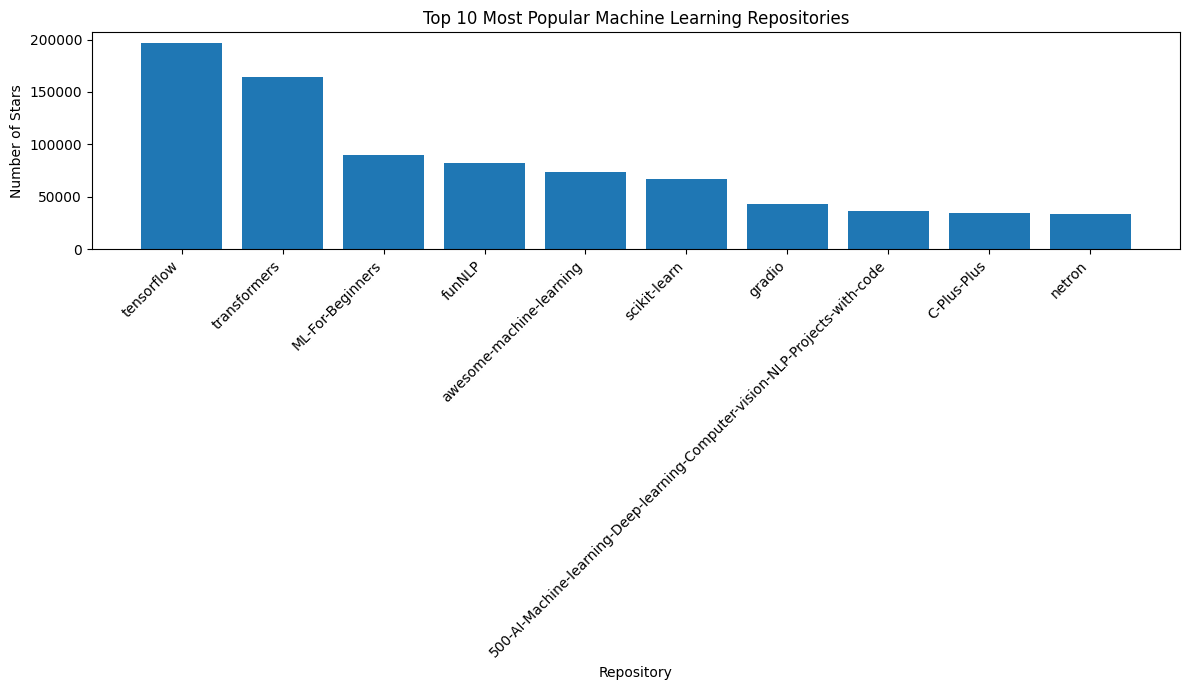

In [56]:
plt.figure(figsize=(12, 7))

plt.bar(
    top10["name"],
    top10["stars"]
)

plt.title(
    "Top 10 Most Popular Machine Learning Repositories"
)

plt.xlabel("Repository")

plt.ylabel("Number of Stars")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [57]:
# ------------------------------------------------------------
# Visualization 2:
# Repository Creation Trends Over Time
# ------------------------------------------------------------

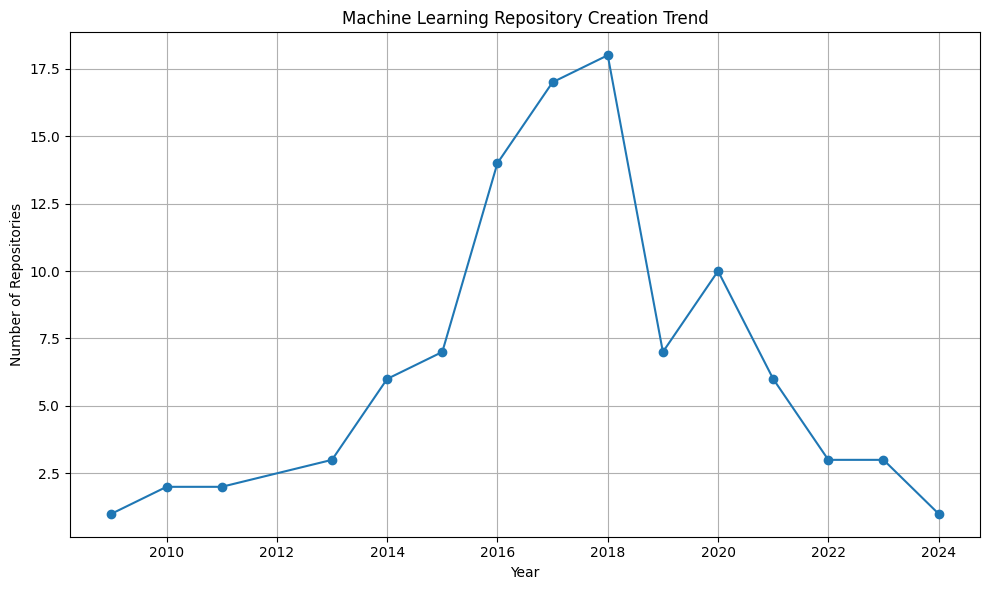

In [58]:
df["created_date"] = pd.to_datetime(
    df["created_date"]
)

df["year"] = df["created_date"].dt.year

creation_trend = (
    df.groupby("year")
    .size()
    .reset_index(name="repository_count")
)

plt.figure(figsize=(10, 6))

plt.plot(
    creation_trend["year"],
    creation_trend["repository_count"],
    marker="o"
)

plt.title(
    "Machine Learning Repository Creation Trend"
)

plt.xlabel("Year")

plt.ylabel("Number of Repositories")

plt.grid(True)

plt.tight_layout()

plt.show()

In [59]:
# ============================================================
# STEP 8 - INTERPRET RESULTS
# ============================================================

In [60]:
print("\n" + "=" * 60)
print("FINAL ANALYSIS SUMMARY")
print("=" * 60)

print(
    f"\nTotal repositories: {total_repositories}"
)

print(
    f"Average stars: {average_stars:.2f}"
)

print("\nTop 10 repositories by stars:")

print(
    top10[
        ["name", "language", "stars"]
    ].to_string(index=False)
)

print(
    "\nProgramming languages with more than 5 repositories:"
)

print(
    language_groups.to_string(index=False)
)


FINAL ANALYSIS SUMMARY

Total repositories: 100
Average stars: 20804.20

Top 10 repositories by stars:
                                                                        name         language  stars
                                                                  tensorflow              C++ 197040
                                                                transformers           Python 164218
                                                            ML-For-Beginners Jupyter Notebook  89485
                                                                      funNLP           Python  82526
                                                    awesome-machine-learning           Python  74061
                                                                scikit-learn           Python  66969
                                                                      gradio           Python  43377
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code          Un

In [61]:
# ------------------------------------------------------------
# Close SQLite connection
# ------------------------------------------------------------

In [62]:
connection.close()

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)


PROJECT COMPLETED SUCCESSFULLY!
